            __python implementation__

In [16]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import preprocessing  # or: from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df=pd.read_csv("loan_approved.csv")  # Loading dataset

In [18]:
df.columns  # Checking coloums of datasets

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)'],
      dtype='object')

In [19]:
df.isnull().sum()  # Checking null values

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

# Imputing Null values

In [20]:
df.loc[df['Gender'].isnull(),'Gender']="Male"  # Filling null value using Most_Frequent Elements of Gender column.

In [21]:
df.loc[df['Married'].isnull(),'Married']="Yes"    # Filling null value using Most_Frequent Elements of Married column.

In [22]:
df.loc[df['Dependents'].isnull(),'Dependents']='0'   # Filling null value using Most_Frequent Elements of Dependents

In [23]:
df.loc[df['Self_Employed'].isnull(),'Self_Employed']='No'   # Filling null value using Most_Frequent Elements of Self_Employed

In [24]:
#  Filling null values using Median of LoanAmount
df.loc[df['LoanAmount'].isnull(),'LoanAmount']=df['LoanAmount'].median()

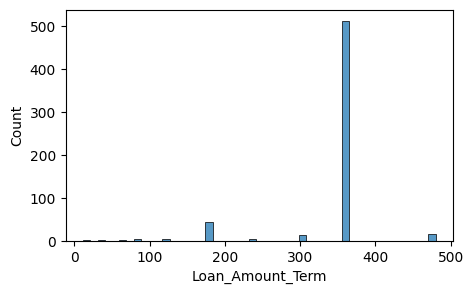

In [25]:

plt.figure(figsize=(5, 3))
sns.histplot(x='Loan_Amount_Term', data=df)
plt.show()

In [26]:
#  Filling null values using Most_Frequent value of Loan_Amount_Term column
df.loc[df['Loan_Amount_Term'].isnull(),'Loan_Amount_Term']=360.0

In [27]:
df.loc[df['Credit_History'].isnull(),'Credit_History']=0.0    # Filling null values of Credit_History

In [28]:
df.isnull().sum()   # Checking null values are available or not

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

# Loading preprocessor

In [29]:
# Load a preprocessor object from a pickled file
with open("preprocessor.pkl","rb") as f:
    preprocessor=pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'preprocessor.pkl'

In [15]:
preprocessor  # Preprocessor or PipeLine

ColumnTransformer(transformers=[('OHE columns', OneHotEncoder(),
                                 ['Self_Employed', 'Property_Area', 'Gender']),
                                ('Label_encoder', ModifiedLabelEncoder(),
                                 ['Married']),
                                ('standard_scaler', StandardScaler(),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount']),
                                ('custom',
                                 FunctionTransformer(func=<function divide_by_12 at 0x0000018F8FD383A0>),
                                 ['Loan_Amount_Term']),
                                ('pass through',
                                 FunctionTransformer(func=<function same at 0x0000018F9577F3A0>),
                                 ['Credit_History']),
                                ('ordinal dependents',
                                 OrdinalEncoder(categories=[['0', '1', '2',
                                                             '3+']]),
                                 ['Dependents']),
                                ('ordinal education',
                                 OrdinalEncoder(categories=[['Not Graduate',
                                                             'Graduate']]),
                                 ['Education']),
                                ('Label Label encoder', ModifiedLabelEncoder(),
                                 ['Loan_Status (Approved)'])])

# Splitting the data

In [16]:
df.shape

(614, 13)

In [17]:
# Spliting the data into train and test
train,test,_,_=train_test_split(df,df['LoanAmount'],test_size=0.2)

In [18]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
386,LP002239,Male,No,0,Not Graduate,No,2346,1600.0,132.0,360.0,1.0,Semiurban,Y
186,LP001641,Male,Yes,1,Graduate,Yes,2178,0.0,66.0,300.0,0.0,Rural,N
343,LP002126,Male,Yes,3+,Not Graduate,No,3173,0.0,74.0,360.0,1.0,Semiurban,Y
462,LP002487,Male,Yes,0,Graduate,No,3015,2188.0,153.0,360.0,1.0,Rural,Y
499,LP002602,Male,No,0,Graduate,No,6283,4416.0,209.0,360.0,0.0,Rural,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,LP001786,Male,Yes,0,Graduate,No,5746,0.0,255.0,360.0,0.0,Urban,N
366,LP002187,Male,No,0,Graduate,No,2500,0.0,96.0,480.0,1.0,Semiurban,N
442,LP002418,Male,No,3+,Not Graduate,No,4707,1993.0,148.0,360.0,1.0,Semiurban,Y
37,LP001112,Female,Yes,0,Graduate,No,3667,1459.0,144.0,360.0,1.0,Semiurban,Y


In [19]:
train['Loan_Status (Approved)'].value_counts()  # Checking count of unique values of Loan_Status (Approved) columns

Loan_Status (Approved)
Y    333
N    158
Name: count, dtype: int64

# Transforming the data

In [20]:
# Transform the training data using the preprocessor object or PipeLine
processed_data=preprocessor.fit_transform(train)

In [21]:
processed_data

array([[1., 0., 0., ..., 0., 0., 1.],
       [0., 1., 1., ..., 1., 1., 0.],
       [1., 0., 0., ..., 3., 0., 1.],
       ...,
       [1., 0., 0., ..., 3., 0., 1.],
       [1., 0., 0., ..., 0., 1., 1.],
       [1., 0., 0., ..., 0., 1., 1.]])

In [22]:
# Extract the features (all columns except the last one) from the processed data
x_train=processed_data[:,:-1]

In [23]:
# Extract the target variable (last column) from the processed data
y_train=processed_data[:,-1] # Last column is target

In [24]:
y_train

array([1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 1.,
       0., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1.,
       0., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1.,
       1., 1., 0., 1., 0.

# Balancing the data

## SMOTE

In [25]:
#!pip install imblearn

In [26]:
# Initialize the SMOTE (Synthetic Minority Over-sampling Technique) object into variable
smote=SMOTE()

In [27]:
# Apply SMOTE to the training data to balance the class distribution
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [28]:
len(y_train)  # Checking length of actual y_train

491

In [29]:
len(y_train_smote)   # Checking length of y_train after apply Smote

666

In [30]:
pd.Series(y_train_smote).value_counts()

1.0    333
0.0    333
Name: count, dtype: int64

# Model Building

SVM is the Supervised Machine Learning algorithm used for both classification, regression. But mostly preferred for classification.

Given a dataset, the algorithm tries to divide the data using hyperplanes and then makes the predictions. SVM is a non-probabilistic linear classifier. While other classifiers, when classifying, predict the probability of a data point to belong to one group or the another, SVM directly says to which group the datapoint belongs to without using any probability calculation.

How it works?

SVM constructs a best line or the decision boundary called Hyperplane which can be used for classification or regression or outlier detection. The dimension of the hyperplane depends upon the number of features. If the number of input features is 2, then the hyperplane is just a line. If the number of input features is 3, then the hyperplane becomes a two-dimensional plane.

This hyperplane creates 2 margin lines parallel to it which have some distance so that it can distinctly classify the data points. The distance between the 2 margin lines are called marginal distance.

These 2 margin lines passes through the most nearest +ve points and the most nearest -ve points. Those points through which the margin lines pass are called support vectors. Support vectors are important as it helps to determine the maximum distance of the marginal plane.

## Understanding the Mathematics involved

Let’s take the example of the following dataset and see how can we divide the data into appropriate groups.

We can see that there are two groups of data. The question is how to divide these points into two groups. It can be done using any of the three lines. Or, for that purpose, there can be an infinite number of straight lines that can divide these points into two classes. Now, which line to choose? SVM solves this problem using the maximum margin as shown

The black line in the middle is the optimum classifier. This line is drawn to maximise the distance of the classifier line from the nearest points in the two classes. It is also called a hyperplane in terms of SVM. A Hyperplane is an n-1 dimensional plane which optimally divides the data of n dimensions. Here, as we have only a 2-D data, so the hyperplane can be represented using one dimension only. Hence, the hyperplane is a line here. The two points (highlighted with circles) which are on the yellow lines, they are called the support vectors. As it is a 2-D figure, they are points. In a multi-dimensional space, they will be vectors, and hence, the name- support vector machine as the algorithm creates the optimum classification line by maximising its distance from the two support vectors.

When the data is not linearly separable, then to create a hyperplane to separate data into different groups, the SVM algorithm needs to perform computations in a higher-dimensional space. But the introduction of new dimensions makes the computations for the SVMs more intensive, which impacts the algorithm performance. To rectify this, mathematicians came up with the approach of Kernel methods. Kernel methods use kernel functions available in mathematics. The unique feature of a kernel function is to compute in a higher-dimensional space without calculating the new coordinates in that higher dimension. It implicitly uses predefined mathematical functions to do operations on the existing points which mimic the computation in a higher-dimensional space without adding to the computation cost as they are not actually calculating the coordinates in the higher dimension thereby avoiding the computation of calculating distances from the newly computed points. This is called the kernel trick.  Image: bogotobogo.com

In the left diagram above, we have a non-linear distribution of data as we can not classify a data using a linear equation. To solve this problem, we can project the points in a 3-dimensional space and then derive a plane which divides the data into two parts. In theory, that’s what a kernel function does without computing the additional coordinates for the higher dimension.

In [31]:
x_train_smote

array([[1.        , 0.        , 0.        , ..., 1.        , 0.        ,
        0.        ],
       [0.        , 1.        , 1.        , ..., 0.        , 1.        ,
        1.        ],
       [1.        , 0.        , 0.        , ..., 1.        , 3.        ,
        0.        ],
       ...,
       [1.        , 0.        , 0.        , ..., 0.        , 2.61819839,
        0.        ],
       [1.        , 0.        , 1.        , ..., 1.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.        , ..., 0.321455  , 0.321455  ,
        1.        ]])

In [32]:
from sklearn.svm import SVC  # # assign Support vector classifier
svclassifier = SVC() ## base model with default hyper parameters
svclassifier.fit(x_train_smote,y_train_smote)  ## Fit the SVC to the resampled training data

SVC()

# Validating the model

### Proessing the test data

In [40]:
test

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
78,LP001263,Male,Yes,3+,Graduate,No,3167,4000.0,180.0,300.0,0.0,Semiurban,N
117,LP001405,Male,Yes,1,Graduate,No,2214,1398.0,85.0,360.0,0.0,Urban,Y
358,LP002158,Male,Yes,0,Not Graduate,No,3000,1666.0,100.0,480.0,0.0,Urban,N
227,LP001758,Male,Yes,2,Graduate,No,6250,1695.0,210.0,360.0,1.0,Semiurban,Y
276,LP001903,Male,Yes,0,Graduate,No,3993,3274.0,207.0,360.0,1.0,Semiurban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,LP001280,Male,Yes,2,Not Graduate,No,3333,2000.0,99.0,360.0,0.0,Semiurban,Y
517,LP002682,Male,Yes,0,Not Graduate,No,3074,1800.0,123.0,360.0,0.0,Semiurban,N
367,LP002188,Male,No,0,Graduate,No,5124,0.0,124.0,360.0,0.0,Rural,N
199,LP001673,Male,No,0,Graduate,Yes,11000,0.0,83.0,360.0,1.0,Urban,N


In [41]:
test_processed=preprocessor.transform(test)  # Transform the test data using the preprocessor

In [42]:
test_processed

array([[1., 0., 0., ..., 3., 1., 0.],
       [1., 0., 0., ..., 1., 1., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 1., ..., 0., 1., 0.],
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 1., 1., ..., 2., 1., 1.]])

In [43]:
x_test=test_processed[:,:-1]  # Extract the features (all columns except the last one) from the processed data
y_test=test_processed[:,-1]   # Extract the target variable (last column) from the processed data

In [44]:
y_test   # it is actual data

array([0., 1., 0., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 1., 0., 1.,
       1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1.,
       1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1.,
       0., 0., 0., 1.])

In [45]:
# Getting predictions from model
y_pred=svclassifier.predict(x_test)

In [46]:
y_pred

array([1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 1., 1., 1., 0.,
       1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1.,
       1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1.])

### Evaluating the model performance

In [47]:
# Importing the classification_report function from sklearn.metrics
from sklearn.metrics import classification_report
# Printing the classification report comparing the true labels (y_test) and the predicted labels (y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.50      0.32      0.39        34
         1.0       0.77      0.88      0.82        89

    accuracy                           0.72       123
   macro avg       0.64      0.60      0.61       123
weighted avg       0.70      0.72      0.70       123



In [48]:
pd.Series(y_test == y_pred).mean().round(2)

0.72

# Hyper Parameter Tuning

## What is a Model Hyperparameter?

A model hyperparameter is a configuration that is external to the model and whose value cannot be estimated from data.



## Hyperparameters of Support Vector Machine

#### SVM separates data points that belong to different classes with a decision boundary. When determining the decision boundary, a soft margin SVM (soft margin means allowing some data points to be misclassified) tries to solve an optimization problem with the following goals:

#### 1)Increase the distance of decision boundary to classes (or support vectors)
#### 2)Maximize the number of points that are correctly classified in the training set

### There is obviously a trade-off between these two goals which and it is controlled by C which adds a penalty for each misclassified data point.

### If C is small, the penalty for misclassified points is low so a decision boundary with a large margin is chosen at the expense of a greater number of misclassification.

### If C is large, SVM tries to minimize the number of misclassified examples due to the high penalty which results in a decision boundary with a smaller margin. The penalty is not the same for all misclassified examples. It is directly proportional to the distance to the decision boundary.

### Gamma is a hyperparameter used with non-linear SVM. One of the most commonly used non-linear kernels is the radial basis function (RBF). Gamma parameter of RBF controls the distance of the influence of a single training point.

### Low values of gamma indicate a large similarity radius which results in more points being grouped together.

### For high values of gamma, the points need to be very close to each other in order to be considered in the same group (or class). Therefore, models with very large gamma values tend to overfit.

## GridSearchCV

#### It is the process of performing hyperparameter tuning in order to determine the optimal values for a given model. As mentioned above, the performance of a model significantly depends on the value of hyperparameters

#### Doing this manually could take a considerable amount of time and resources and thus we use GridSearchCV to automate the tuning of hyperparameters.

GridSearchCV tries all the combinations of the values passed in the m

dictionary and evaluates the model for each combination using the Cross-Validation method. Hence after using this function we get accuracy/loss for every combination of hyperparameters and we can choose the one with the best performance.

In [49]:
from itertools import product  # Importing the product function from the itertools module

param_grid_linear = {           #  Define Parameter grid for linear kernel SVM
    'C': [0.1, 5, 10,50,60,70],
    'kernel': ['linear'],
    'gamma': ['scale', 'auto']
}
param_grid_rbf = {              # Define Parameter grid for Radial Basis Function-RBF
    'C': [0.1, 5, 10,50,60,70],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}
param_grid_poly = {             # Define Parameters grid for Polynomial kernel
    'C': [0.1, 5, 10,50,60,70],
    'kernel': ['poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

In [52]:
# Importing GridSearchCV from sklearn
from sklearn.model_selection import GridSearchCV

# Assigning SVC model into variables
model=SVC()

# Defining the grid search using GridSearchCV
# - The parameter grid is defined by param_grid_poly
# - 'refit=True' ensures that the best estimator found during the grid search is refitted on the whole dataset
# - 'verbose=2' controls the verbosity of the grid search process (higher values result in more output)
# - 'scoring='f1'' specifies the scoring metric for evaluating the model's performance during grid search
# - 'cv=5' specifies 5-fold cross-validation for evaluating each combination of hyperparameters
grid = GridSearchCV(model,param_grid=param_grid_rbf, refit = True, verbose = 1,scoring='f1',cv=3)

# fitting the model for grid search
grid.fit(x_train_smote,y_train_smote)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 5, 10, 50, 60, 70],
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [53]:
# Opening a file named "model.pkl" in write-binary mode
# The 'wb' mode is used for writing binary data to the file
with open("model.pkl","wb") as f:
    pickle.dump(grid,f)      # Using pickle to serialize and save the grid search object to the file

In [54]:
print(grid.best_params_)   # Printing the best parameters found by the grid search

{'C': 60, 'gamma': 'scale', 'kernel': 'rbf'}


In [55]:
grid

GridSearchCV(cv=3, estimator=SVC(),
             param_grid={'C': [0.1, 5, 10, 50, 60, 70],
                         'gamma': ['scale', 'auto'], 'kernel': ['rbf']},
             scoring='f1', verbose=1)

In [58]:

svclassifier = SVC(C=60, gamma='auto',kernel='rbf' ) ## base model with best hyper paramters
svclassifier.fit(x_train_smote,y_train_smote)

SVC(C=60, gamma='auto')

In [59]:
y_hat=grid.predict(x_test)  # Use the best model from grid search to make predictions on the test set

In [60]:
# Generate a classification report comparing true labels (y_test) with predicted labels (y_hat)
print(classification_report(y_test,y_hat))

              precision    recall  f1-score   support

         0.0       0.77      0.71      0.74        34
         1.0       0.89      0.92      0.91        89

    accuracy                           0.86       123
   macro avg       0.83      0.81      0.82       123
weighted avg       0.86      0.86      0.86       123

